# Day 31: Building Customer Personas from Our Clusters
Today, I'm taking the K-Means clustering results from yesterday ($K=5$) and turning those mathematical groups into real-world customer personas. It's really cool to see how we can combine numbers (income and spending score) with demographics (age and gender) to understand who these customers actually are and how a business can target them.


## 1. Imports and Setting up the Plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("All libraries loaded!")


All libraries loaded!


## 2. Loading the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Data shape:", df.shape)
df.head()


Data shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Running K-Means with K=5 (from yesterday's optimization)

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale to prevent income (thousands) from dominating spending score (1-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("How customers are split across the 5 clusters:")
print(df['Cluster'].value_counts())


How customers are split across the 5 clusters:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


## 4. Defining and Mapping the Customer Personas

In [4]:
cluster_stats = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster means:")
print(cluster_stats.round(1))

# Custom mapping function based on cluster means
def identify_persona(row):
    income = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    if income > 70 and spend > 60:
        return 'The Elite Affluents'
    elif income > 70 and spend < 40:
        return 'The Affluent Frugals'
    elif income < 40 and spend > 60:
        return 'The Impulsive Budgeters'
    elif income < 40 and spend < 40:
        return 'The Value Seekers'
    else:
        return 'The Steady Conformists'

cluster_to_persona = {}
for i in range(5):
    inc_mean = cluster_stats.loc[i, 'Annual Income (k$)']
    spd_mean = cluster_stats.loc[i, 'Spending Score (1-100)']
    persona = identify_persona({'Annual Income (k$)': inc_mean, 'Spending Score (1-100)': spd_mean})
    cluster_to_persona[i] = persona

df['Persona'] = df['Cluster'].map(cluster_to_persona)
print("\nMapping results:")
for k, v in cluster_to_persona.items():
    print(f"Cluster {k} -> {v}")


Cluster means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      25.7                    79.4
3                      88.2                    17.1
4                      26.3                    20.9

Mapping results:
Cluster 0 -> The Steady Conformists
Cluster 1 -> The Elite Affluents
Cluster 2 -> The Impulsive Budgeters
Cluster 3 -> The Affluent Frugals
Cluster 4 -> The Value Seekers


## 5. Visualizing the 5 Customer Personas

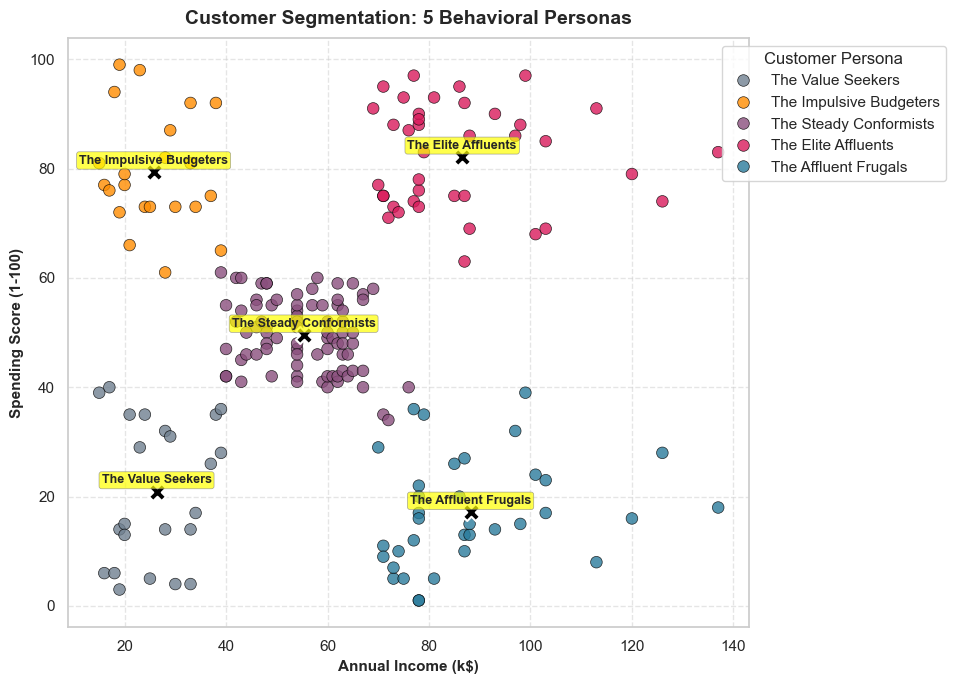

In [5]:
plt.figure(figsize=(10, 7))

colors = {
    'The Elite Affluents': '#D91A5B',
    'The Affluent Frugals': '#2A7B9B',
    'The Steady Conformists': '#8A4F7D',
    'The Impulsive Budgeters': '#FF8C00',
    'The Value Seekers': '#708090'
}

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Persona',
    palette=colors,
    s=70,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Convert centroids back to original scale to plot them correctly
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

for idx, (cx, cy) in enumerate(centroids_orig):
    name = cluster_to_persona[idx]
    plt.scatter(cx, cy, c='black', marker='X', s=150, edgecolor='white', linewidth=1.5, zorder=10)
    plt.annotate(
        name,
        xy=(cx, cy),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7, ec='grey', lw=0.5),
        zorder=11
    )

plt.title('Customer Segmentation: 5 Behavioral Personas', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Annual Income (k$)', fontweight='bold')
plt.ylabel('Spending Score (1-100)', fontweight='bold')
plt.legend(title='Customer Persona', loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('customer_personas_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Demographic Profiling (Age and Gender details)

In [6]:
persona_demographics = df.groupby('Persona').agg({
    'Age': ['mean', 'min', 'max', 'count'],
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(1)

print("Demographic and Behavioral averages per persona:")
print(persona_demographics)

gender_counts = df.groupby(['Persona', 'Gender']).size().unstack(fill_value=0)
gender_percentages = (gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100).round(1)
print("\nGender Split (%) per Persona:")
print(gender_percentages)


Demographic and Behavioral averages per persona:
                          Age               Annual Income (k$)  \
                         mean min max count               mean   
Persona                                                          
The Affluent Frugals     41.1  19  59    35               88.2   
The Elite Affluents      32.7  27  40    39               86.5   
The Impulsive Budgeters  25.3  18  35    22               25.7   
The Steady Conformists   42.7  18  70    81               55.3   
The Value Seekers        45.2  19  67    23               26.3   

                        Spending Score (1-100)  
                                          mean  
Persona                                         
The Affluent Frugals                      17.1  
The Elite Affluents                       82.1  
The Impulsive Budgeters                   79.4  
The Steady Conformists                    49.5  
The Value Seekers                         20.9  

Gender Split (%) per Persona:

## 7. Plotting Demographic Distributions Across Personas

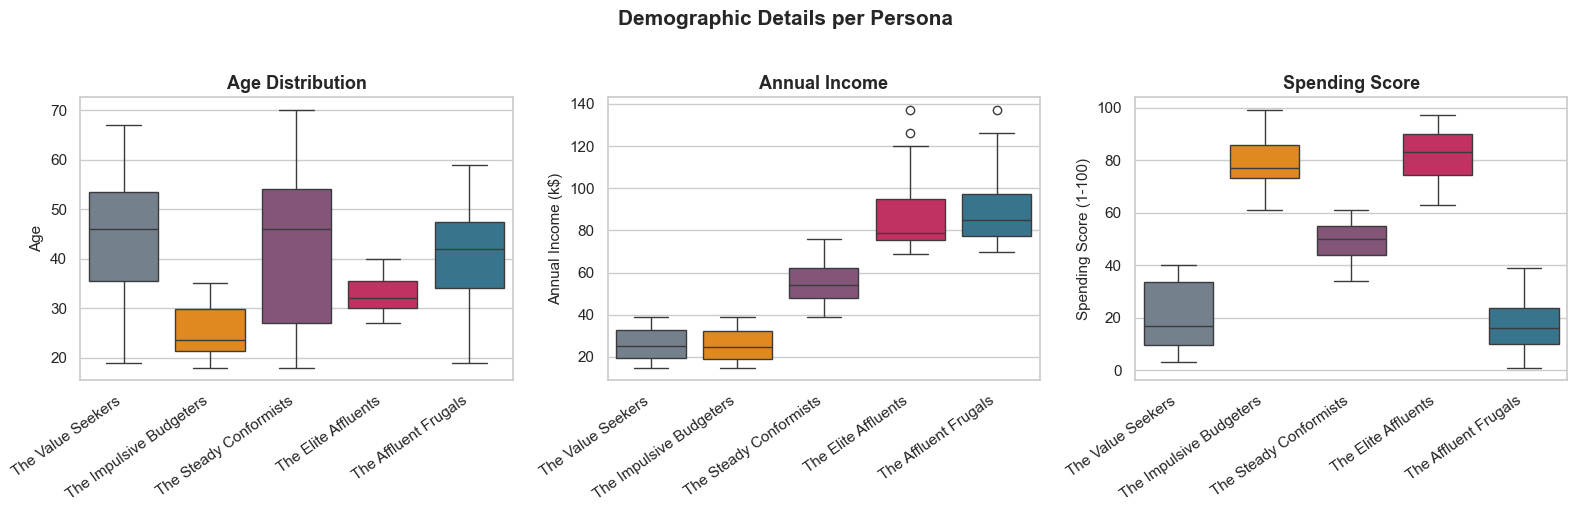

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ordered_personas = [
    'The Value Seekers', 
    'The Impulsive Budgeters', 
    'The Steady Conformists', 
    'The Elite Affluents', 
    'The Affluent Frugals'
]

sns.boxplot(data=df, x='Persona', y='Age', ax=axes[0], order=ordered_personas, palette=colors)
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Persona', y='Annual Income (k$)', ax=axes[1], order=ordered_personas, palette=colors)
axes[1].set_title('Annual Income', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].set_xlabel('')

sns.boxplot(data=df, x='Persona', y='Spending Score (1-100)', ax=axes[2], order=ordered_personas, palette=colors)
axes[2].set_title('Spending Score', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=35, ha='right')
axes[2].set_xlabel('')

plt.suptitle('Demographic Details per Persona', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('persona_demographics.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Plotting Gender Split per Persona

<Figure size 900x550 with 0 Axes>

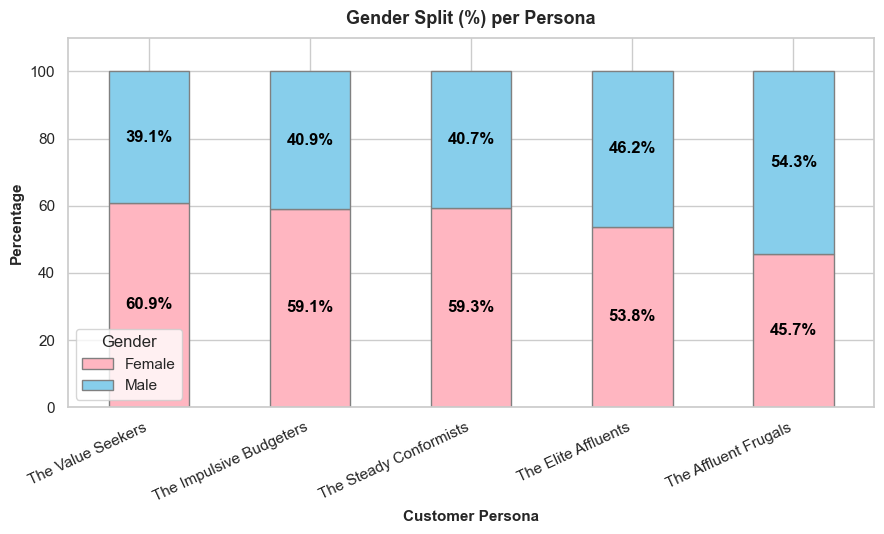

In [8]:
plt.figure(figsize=(9, 5.5))

gender_percentages.loc[ordered_personas].plot(
    kind='bar',
    stacked=True,
    color=['#FFB6C1', '#87CEEB'],
    edgecolor='grey',
    figsize=(9, 5.5)
)

plt.title('Gender Split (%) per Persona', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Customer Persona', fontweight='bold')
plt.ylabel('Percentage', fontweight='bold')
plt.legend(title='Gender', loc='lower left')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 110)

for idx, persona in enumerate(ordered_personas):
    fem_pct = gender_percentages.loc[persona, 'Female']
    male_pct = gender_percentages.loc[persona, 'Male']
    
    plt.text(idx, fem_pct / 2, f"{fem_pct}%", ha='center', va='center', color='black', fontweight='bold')
    plt.text(idx, fem_pct + (male_pct / 2), f"{male_pct}%", ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('persona_gender_split.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Creating the Summary Table & Exporting Labeled Data

In [9]:
summary = df.groupby('Persona').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda g: f"{(g == 'Female').mean()*100:.1f}% Female / {100 - (g == 'Female').mean()*100:.1f}% Male"
}).rename(columns={
    'CustomerID': 'Count',
    'Age': 'Avg Age',
    'Annual Income (k$)': 'Avg Income ($k)',
    'Spending Score (1-100)': 'Avg Spend Score',
    'Gender': 'Gender Ratio'
})

summary = summary.reindex(ordered_personas)
summary['% of Total'] = (summary['Count'] / len(df) * 100).round(1)
summary = summary[['Count', '% of Total', 'Avg Age', 'Gender Ratio', 'Avg Income ($k)', 'Avg Spend Score']]

print("Summary Table:")
print(summary)

summary.to_csv("customer_personas_summary.csv")
df.to_csv("Mall_Customers_Labeled_Personas.csv", index=False)
print("\nFiles saved to csv!")


Summary Table:
                         Count  % of Total    Avg Age  \
Persona                                                 
The Value Seekers           23        11.5  45.217391   
The Impulsive Budgeters     22        11.0  25.272727   
The Steady Conformists      81        40.5  42.716049   
The Elite Affluents         39        19.5  32.692308   
The Affluent Frugals        35        17.5  41.114286   

                                      Gender Ratio  Avg Income ($k)  \
Persona                                                               
The Value Seekers        60.9% Female / 39.1% Male        26.304348   
The Impulsive Budgeters  59.1% Female / 40.9% Male        25.727273   
The Steady Conformists   59.3% Female / 40.7% Male        55.296296   
The Elite Affluents      53.8% Female / 46.2% Male        86.538462   
The Affluent Frugals     45.7% Female / 54.3% Male        88.200000   

                         Avg Spend Score  
Persona                                   
T

## 10. Ideas and Marketing Strategies for Each Persona

Based on the statistical and demographic details we found, here are some actionable strategies:

### 1. **The Elite Affluents** (High Income, High Spend)
* **Who they are:** Highly active, young (average age 32.7) high-earners. There are slightly more women here (53.8%).
* **How to target:**
  - Create a VIP program with exclusive tier rewards and early access.
  - Send personal invitations for private sales or new collections.
  - Offer personal shopping services to make buying as easy as possible.

### 2. **The Affluent Frugals** (High Income, Low Spend)
* **Who they are:** Older (average age 41.1) and slightly male-skewed (51.4% Male) who make a lot but don't spend.
* **How to target:**
  - They are rational shoppers, so highlight product specs, longevity, and warranties.
  - Position purchases as long-term investments, not short-term trends.
  - Avoid high-pressure sales pitches; focus on user reviews and utility.

### 3. **The Steady Conformists** (Mid Income, Mid Spend)
* **Who they are:** The massive middle class, average age 42.7. Represents 40.5% of our customers.
* **How to target:**
  - Use standard loyalty points programs (e.g., spend money, get points).
  - Re-engage them through regular newsletters, discounts, and brand familiarity.
  - Highlight popular items and reviews to show others buy them.

### 4. **The Impulsive Budgeters** (Low Income, High Spend)
* **Who they are:** Very young crowd (average age 25.3), mostly women (59.1%). High spending despite low income.
* **How to target:**
  - Partner with influencers and run aesthetic TikTok/Instagram campaigns.
  - Use limited-time coupon codes or flash sales to trigger impulse purchases.
  - Integrate "Buy Now, Pay Later" (BNPL) checkout options.

### 5. **The Value Seekers** (Low Income, Low Spend)
* **Who they are:** Older (average age 45.2), female-skewed (60.9%) budget shoppers.
* **How to target:**
  - Target them strictly with discount racks, BOGO deals, and coupon emails.
  - Keep marketing costs low by sending simple SMS messages instead of expensive ads.
  - Focus on bulk purchase deals or clearance sales.
